Présentation
L'entreprise TouNum travaille sur la numérisation de documents (textes, images...). Leurs services sont souvent requis par des entreprises numérisant leur base de documents papier. Ils souhaitent étendre leur gamme de services pour inclure des outils de Machine Learning. En effet, certains de leurs clients ont une grande quantité de données à numériser, et un service de catégorisation automatique serait plus que valorisable.

TouNum n'a pas dans son personnel de spécialiste du Machine Learning. L'entreprise fait appel à vous, les spécialistes en Data Science de CESI. On vous propose un premier contrat pour travailler sur une solution visant à analyser des photographies pour en déterminer une légende descriptive de manière automatique (du captioning).

In [26]:
import pathlib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import cv2
import os
import PIL
from tensorflow.keras import models
from tensorflow.keras.models import Sequential
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers , callbacks
from tensorflow.keras.models import Sequential
%matplotlib inline

In [27]:
import os, unicodedata

data_dir = "DATASET"


In [28]:
for root, _, files in os.walk(data_dir):
    for file in files:
        new_name = unicodedata.normalize("NFKD", file).encode("ascii", "ignore").decode("ascii")
        new_name = new_name.replace(" ", "_")
        old_path = os.path.join(root, file)
        new_path = os.path.join(root, new_name)
        if old_path != new_path:
            os.rename(old_path, new_path)
            print(f"Renommé : {old_path} -> {new_path}")

Renommé : DATASET\Dataset_Livrable_1_Painting\Eijin Suzuki voiture rouge.jpg -> DATASET\Dataset_Livrable_1_Painting\Eijin_Suzuki_voiture_rouge.jpg
Renommé : DATASET\Dataset_Livrable_1_Photo\image0 (1).jpg -> DATASET\Dataset_Livrable_1_Photo\image0_(1).jpg


In [29]:
for files in os.walk("Projet/DATASET"):
    for file in files:
        new_image = Image.new()

In [30]:
# --- hyperparamètres (ajuste si besoin) ---
image_h, image_w = 128, 128   # mettre la taille que tu utilises
num_classes = 5               # adapte selon ton dataset
batch_size = 64
epochs = 10


In [31]:
def augment_and_save(img_path, save_dir):
    img = cv2.imread(img_path)

    # Flou
    blur = cv2.GaussianBlur(img, (5,5), 0)
    cv2.imwrite(os.path.join(save_dir, "blur.jpg"), blur)

    # Noir & blanc
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    cv2.imwrite(os.path.join(save_dir, "gray.jpg"), gray)

    # Rotation
    h, w = img.shape[:2]
    M = cv2.getRotationMatrix2D((w//2,h//2), 30, 1)
    rotated = cv2.warpAffine(img, M, (w,h))
    cv2.imwrite(os.path.join(save_dir, "rotated.jpg"), rotated)

In [32]:
# --- Data augmentation (optionnel mais recommandé) ---
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal", input_shape=(image_h, image_w, 3)),
    layers.RandomRotation(0.3),
    layers.RandomZoom(0.3),
    layers.RandomContrast(0.3),
])

In [33]:
# Dataset train
train_set = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(image_h, image_w),
    batch_size=batch_size,
    label_mode="int"
)

# Dataset test
test_set = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(image_h, image_w),
    batch_size=batch_size,
    label_mode="int"
)

# ⚡️ Ici on applique ignore_errors
train_set = train_set.apply(tf.data.experimental.ignore_errors())
test_set  = test_set.apply(tf.data.experimental.ignore_errors())


Found 41409 files belonging to 5 classes.
Using 33128 files for training.
Found 41409 files belonging to 5 classes.
Using 8281 files for validation.


In [34]:
# --- Modèle CNN basique ---
model = models.Sequential([
    data_augmentation,
    layers.Rescaling(1./255),  # normalisation

    # Bloc 1
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # Bloc 2
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    # Bloc 3 (un peu plus profond)
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

In [35]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',  # si tes labels sont des entiers (0..num_classes-1)
    metrics=['accuracy']
)
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_5 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,288,325 (16.36 MB)

 Trainable params: 4,288,325 (16.36 MB)

 Non-trainable params: 0 (0.00 B)

In [36]:
# --- Callbacks utiles ---
es = callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
ckpt = callbacks.ModelCheckpoint('best_model.h5', monitor='val_loss', save_best_only=True)


In [ ]:
# --- Entraînement ---
# Supposons que train_set et test_set sont des tf.data.Dataset (ou image_dataset_from_directory)
# Si tu utilises ImageDataGenerator ou autre, adapte l'appel .fit()
history = model.fit(
    train_set,
    validation_data=test_set,
    epochs=epochs
)


Epoch 1/10
     86/Unknown 35s 380ms/step - accuracy: 0.3740 - loss: 1.3575

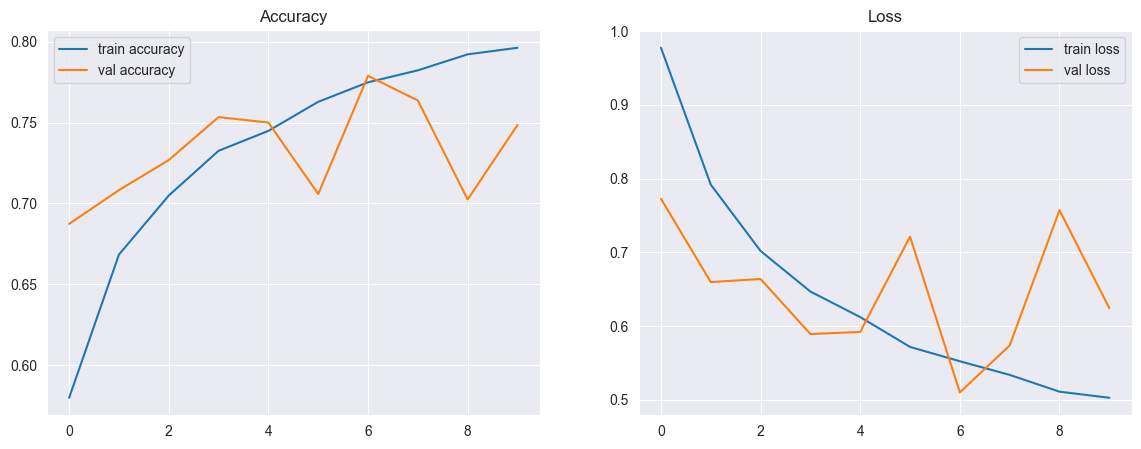

In [25]:
# --- Tracer les courbes (accuracy & loss) ---
acc = history.history.get('accuracy', [])
val_acc = history.history.get('val_accuracy', [])
loss = history.history.get('loss', [])
val_loss = history.history.get('val_loss', [])
epochs_range = range(len(acc))

plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
plt.plot(epochs_range, acc, label='train accuracy')
plt.plot(epochs_range, val_acc, label='val accuracy')
plt.legend(); plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(epochs_range, loss, label='train loss')
plt.plot(epochs_range, val_loss, label='val loss')
plt.legend(); plt.title('Loss')
plt.show()

In [24]:
model.save('my_model.keras')  # au lieu d'un dossier
